In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('https://raw.githubusercontent.com/arib168/data/main/50_Startups.csv')
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [2]:
df.shape

(50, 5)

In [3]:
df.dtypes

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

In [4]:
df.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [5]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [6]:
df.tail()

,R&D Spend,Administration,Marketing Spend,State,Profit
45,1000.23,124153.04,1903.93,New York,64926.08
46,1315.46,115816.21,297114.46,Florida,49490.75
47,0.00,135426.92,0.00,California,42559.73
48,542.05,51743.15,0.00,New York,35673.41
49,0.00,116983.80,45173.06,California,14681.40


In [7]:
df.isna().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [8]:
df1=df['State'].value_counts()
df1

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

<BarContainer object of 3 artists>

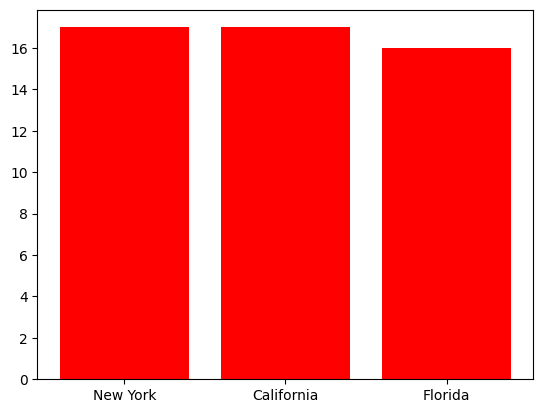

In [9]:
plt.bar(df1.index,df1.values,color='r')

In [10]:
df.corr(numeric_only=True)

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


<Axes: >

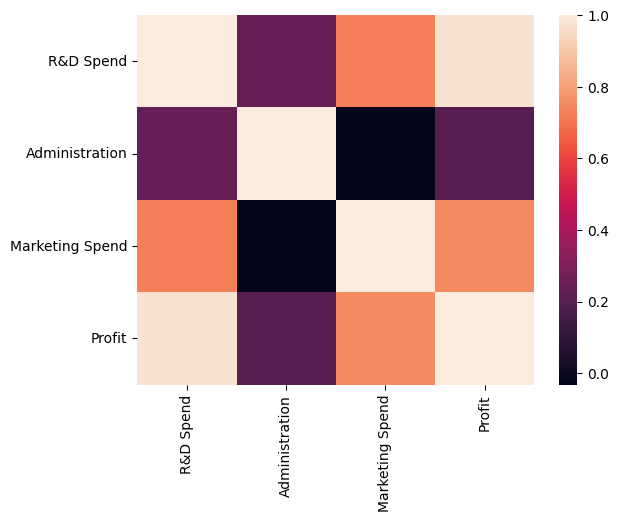

In [11]:
sns.heatmap(df.corr(numeric_only=True))

In [12]:
# OneHot encoding
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
x

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


<Axes: xlabel='R&D Spend', ylabel='Profit'>

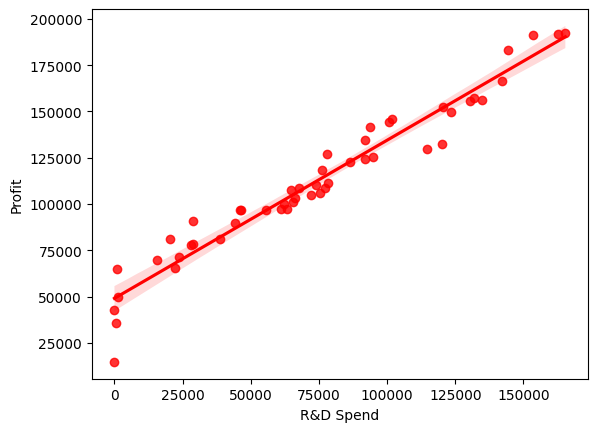

In [13]:
sns.regplot(x=df['R&D Spend'],y=y,color='r')

<Axes: xlabel='Administration', ylabel='Profit'>

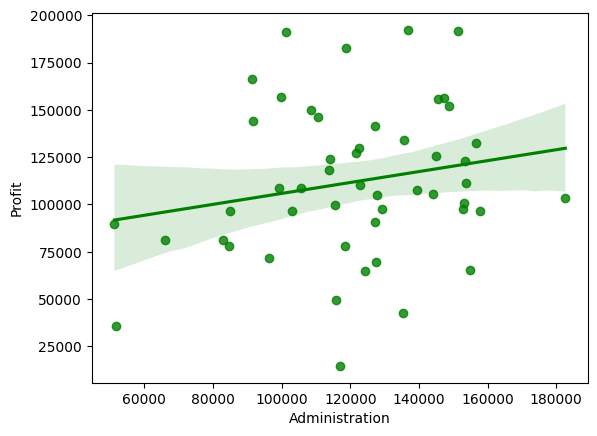

In [14]:
sns.regplot(x=df['Administration'],y=y,color='g')

<Axes: xlabel='Marketing Spend', ylabel='Profit'>

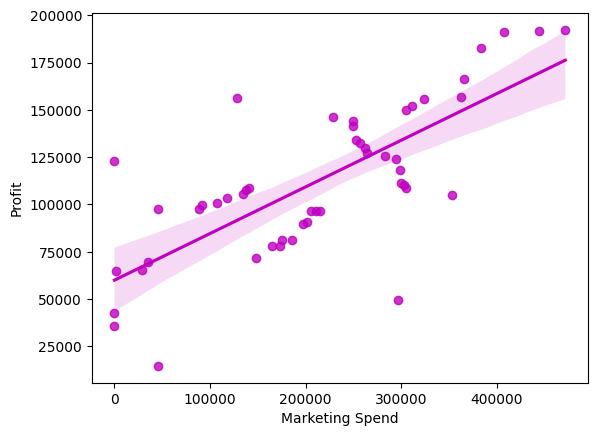

In [15]:
sns.regplot(x=df['Marketing Spend'],y=y,color='m')

In [17]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
col=make_column_transformer((OneHotEncoder(handle_unknown='ignore'),['State']),remainder='passthrough')
x=col.fit_transform(x)
x

array([[0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.6534920e+05,
        1.3689780e+05, 4.7178410e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.6259770e+05,
        1.5137759e+05, 4.4389853e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.5344151e+05,
        1.0114555e+05, 4.0793454e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.4437241e+05,
        1.1867185e+05, 3.8319962e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.4210734e+05,
        9.1391770e+04, 3.6616842e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.3187690e+05,
        9.9814710e+04, 3.6286136e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.3461546e+05,
        1.4719887e+05, 1.2771682e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.3029813e+05,
        1.4553006e+05, 3.2387668e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.2054252e+05,
        1.4871895e+05, 3.1161329e+05],
       [1.0000000e+00, 0.0000000e+00,

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)
x_train

array([[1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.3461546e+05,
        1.4719887e+05, 1.2771682e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 2.7892920e+04,
        8.4710770e+04, 1.6447071e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.3154600e+03,
        1.1581621e+05, 2.9711446e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        1.3542692e+05, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.1452361e+05,
        1.2261684e+05, 2.6177623e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.2333488e+05,
        1.0867917e+05, 3.0498162e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 7.8013110e+04,
        1.2159755e+05, 2.6434606e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 7.7044010e+04,
        9.9281340e+04, 1.4057481e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 4.6426070e+04,
        1.5769392e+05, 2.1079767e+05],
       [0.0000000e+00, 0.0000000e+00,

In [19]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([126187.39411504,  85788.82259513,  99777.0281518 ,  45706.12238331,
       127062.20722771,  51891.83884461, 109114.62977496, 100600.61123703,
        97953.99874718, 111730.57706812, 128818.49200668, 174195.3577263 ,
        93736.28538439, 148381.04097159, 172313.87139387])

In [20]:
df1=pd.DataFrame({'actual value':y_test,'predicted value':y_pred,'difference':y_test-y_pred})
df1

,actual value,predicted value,difference
13,134307.35,126187.394115,8119.955885
39,81005.76,85788.822595,-4783.062595
30,99937.59,99777.028152,160.561848
45,64926.08,45706.122383,19219.957617
17,125370.37,127062.207228,-1691.837228
48,35673.41,51891.838845,-16218.428845
26,105733.54,109114.629775,-3381.089775
25,107404.34,100600.611237,6803.728763
32,97427.84,97953.998747,-526.158747
19,122776.86,111730.577068,11046.282932


In [23]:
print(model.intercept_)

57153.61206246113


In [22]:
print(model.coef_)

[ 2.59028652e+02  7.17099427e+02 -9.76128080e+02  8.04937292e-01
 -9.12577104e-02  2.80672826e-02]


In [27]:
from sklearn.metrics import mean_absolute_percentage_error,r2_score
mape=mean_absolute_percentage_error(y_test,y_pred)
mape

0.08929865344176037

In [28]:
score=r2_score(y_test,y_pred)
score

0.9397108063356006